# 🔍 Fraud Detection Dataset — Mid-Project Analysis

**Course:** Epsilon AI Data Science Program  
**Dataset:** Fraud Detection Dataset (51,000 transactions)  

---

## 📋 Table of Contents
1. [Research Questions](#1)
2. [Import Libraries](#2)
3. [Load & Inspect Data](#3)
4. [Data Cleaning Phase](#4)
5. [Univariate Analysis (1D)](#5)
6. [Bivariate & Multivariate Analysis](#6)
7. [Key Findings & Conclusions](#7)

<a id='1'></a>
## ❓ 1. Research Questions

This project investigates financial transaction data to understand patterns of fraudulent activity. The following questions guide the analysis:

1. **What is the overall fraud rate in this dataset, and is the data imbalanced?**
2. **Do transaction amounts differ significantly between fraudulent and non-fraudulent transactions?**
3. **Which transaction type, payment method, or device is most associated with fraud?**
4. **Does the time of day affect the likelihood of fraud?**
5. **Do users with prior fraudulent transactions have a higher fraud rate?**
6. **Does account age or transaction frequency influence fraud likelihood?**

<a id='2'></a>
## 📦 2. Import Libraries

In [1]:
# ── Standard libraries ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Global plot style ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


<a id='3'></a>
## 📂 3. Load & Inspect Data

In [2]:
import pandas as pd

In [3]:
# ── Load dataset ─────────────────────────────────────────────────────────────
FILE_PATH = 'Fraud_Detection_Dataset.csv'   # adjust path if needed
df = pd.read_csv(FILE_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset shape: 51,000 rows × 12 columns


In [4]:
# ── First five rows ───────────────────────────────────────────────────────────
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [ ]:
# ── Data types ────────────────────────────────────────────────────────────────
df.dtypes

In [ ]:
# ── Descriptive statistics (numeric columns) ──────────────────────────────────
df.describe().T

In [5]:
# ── Helper: summarise missing values ─────────────────────────────────────────
def missing_summary(dataframe):
    """Return a DataFrame showing count and percentage of missing values per column."""
    missing_count = dataframe.isnull().sum()
    missing_pct   = (missing_count / len(dataframe) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': missing_count,
                            'Missing (%)':   missing_pct})
    return summary[summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

missing_summary(df)

,Missing Count,Missing (%)
Time_of_Transaction,2552,5.00
Location,2547,4.99
Transaction_Amount,2520,4.94
Device_Used,2473,4.85
Payment_Method,2469,4.84


<a id='4'></a>
## 🧹 4. Data Cleaning Phase

### Issues identified before cleaning:
| Column | Issue |
|---|---|
| `Transaction_Amount` | ~2,520 missing values (~4.9%) |
| `Time_of_Transaction` | ~2,552 missing values (~5.0%) |
| `Device_Used` | ~2,473 missing + 'Unknown Device' label |
| `Location` | ~2,547 missing values |
| `Payment_Method` | ~2,469 missing + 'Invalid Method' label |

### Cleaning strategy:
- **Numeric missing values** → filled with **median** (robust to outliers)
- **Categorical missing values** → filled with mode (**most frequent category**)
- **'Unknown Device'** and **'Invalid Method'** → treated as a valid separate category (they represent real system states)

In [6]:
# ── Step 1: Copy original to preserve raw data ────────────────────────────────
df_clean = df.copy()

# ── Step 2: Fill numeric missing values with median ───────────────────────────
def fill_numeric_with_median(dataframe, columns):
    """Fill NaN values in numeric columns with the column median."""
    for col in columns:
        median_val = dataframe[col].median()
        dataframe[col].fillna(median_val, inplace=True)
        print(f'  ✔ {col:35s} → filled with median = {median_val:.2f}')

numeric_cols_with_missing = ['Transaction_Amount', 'Time_of_Transaction']
print('Filling numeric columns:')
fill_numeric_with_median(df_clean, numeric_cols_with_missing)

Filling numeric columns:
  ✔ Transaction_Amount                  → filled with median = 2524.10
  ✔ Time_of_Transaction                 → filled with median = 12.00


C:\Users\user\AppData\Local\Temp\ipykernel_1416\3938836897.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[col].fillna(median_val, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_1416\3938836897.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [7]:
# ── Step 3: Fill categorical missing values with mode ─────────────────────────
def fill_categorical_with_mode(dataframe, columns):
    """Fill NaN values in categorical columns with the column mode."""
    for col in columns:
        mode_val = dataframe[col].mode()[0]
        dataframe[col].fillna(mode_val, inplace=True)
        print(f'  ✔ {col:35s} → filled with mode = "{mode_val}"')

categorical_cols_with_missing = ['Device_Used', 'Location', 'Payment_Method']
print('Filling categorical columns:')
fill_categorical_with_mode(df_clean, categorical_cols_with_missing)

Filling categorical columns:
  ✔ Device_Used                         → filled with mode = "Desktop"
  ✔ Location                            → filled with mode = "Boston"
  ✔ Payment_Method                      → filled with mode = "UPI"


C:\Users\user\AppData\Local\Temp\ipykernel_1416\3320238930.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[col].fillna(mode_val, inplace=True)


In [8]:
# ── Step 4: Convert Time_of_Transaction to integer hour ──────────────────────
df_clean['Time_of_Transaction'] = df_clean['Time_of_Transaction'].astype(int)

# ── Step 5: Add a human-readable time period column ──────────────────────────
def classify_time_period(hour):
    """Map an hour (0-23) to a time-of-day period."""
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_clean['Time_Period'] = df_clean['Time_of_Transaction'].apply(classify_time_period)
print('✅ Time_Period column added.')

# ── Final check: no missing values remain ────────────────────────────────────
remaining_missing = df_clean.isnull().sum().sum()
print(f'\nTotal remaining missing values: {remaining_missing}')

✅ Time_Period column added.

Total remaining missing values: 0


In [9]:
# ── Verify cleaned dataset ────────────────────────────────────────────────────
print(f'Clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
df_clean.head()

Clean dataset: 51,000 rows × 13 columns


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,Time_Period
0,T1,4174,1292.76,ATM Withdrawal,16,Tablet,San Francisco,0,119,13,Debit Card,0,Afternoon
1,T2,4507,1554.58,ATM Withdrawal,13,Mobile,New York,4,79,3,Credit Card,0,Afternoon
2,T3,1860,2395.02,ATM Withdrawal,12,Mobile,Boston,3,115,9,UPI,0,Afternoon
3,T4,2294,100.10,Bill Payment,15,Desktop,Chicago,4,3,4,UPI,0,Afternoon
4,T5,2130,1490.50,POS Payment,19,Mobile,San Francisco,2,57,7,Credit Card,0,Evening


<a id='5'></a>
## 📊 5. Univariate Analysis (1D)

Here we explore each variable individually to understand its distribution.

In [11]:
import matplotlib.pyplot as plt

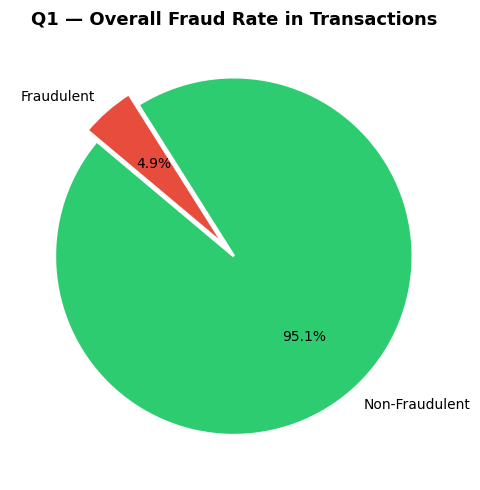

Fraud rate: 4.92%
⚠️  The dataset is highly imbalanced — only ~5% of transactions are fraudulent.


In [12]:
# ── Plot 1: Pie chart — Fraud vs Non-Fraud distribution ──────────────────────
fraud_counts = df_clean['Fraudulent'].value_counts()
labels       = ['Non-Fraudulent', 'Fraudulent']
colors       = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(fraud_counts, labels=labels, autopct='%1.1f%%',
       colors=colors, startangle=140, explode=(0, 0.08),
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Q1 — Overall Fraud Rate in Transactions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fraud_rate = fraud_counts[1] / fraud_counts.sum() * 100
print(f'Fraud rate: {fraud_rate:.2f}%')
print('⚠️  The dataset is highly imbalanced — only ~5% of transactions are fraudulent.')

In [14]:
import matplotlib.ticker as mticker

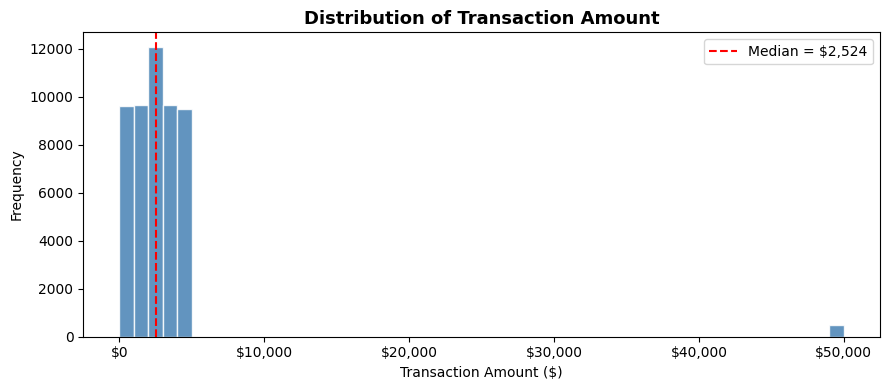

count    51,000.00
mean      2,972.92
std       4,918.80
min           5.03
25%       1,333.79
50%       2,524.10
75%       3,724.99
max      49,997.80
Name: Transaction_Amount, dtype: object


In [15]:
# ── Plot 2: Histogram — Distribution of Transaction Amount ───────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_clean['Transaction_Amount'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Transaction Amount', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add median line
median_amt = df_clean['Transaction_Amount'].median()
ax.axvline(median_amt, color='red', linestyle='--', linewidth=1.5, label=f'Median = ${median_amt:,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(df_clean['Transaction_Amount'].describe().apply(lambda x: f'{x:,.2f}'))

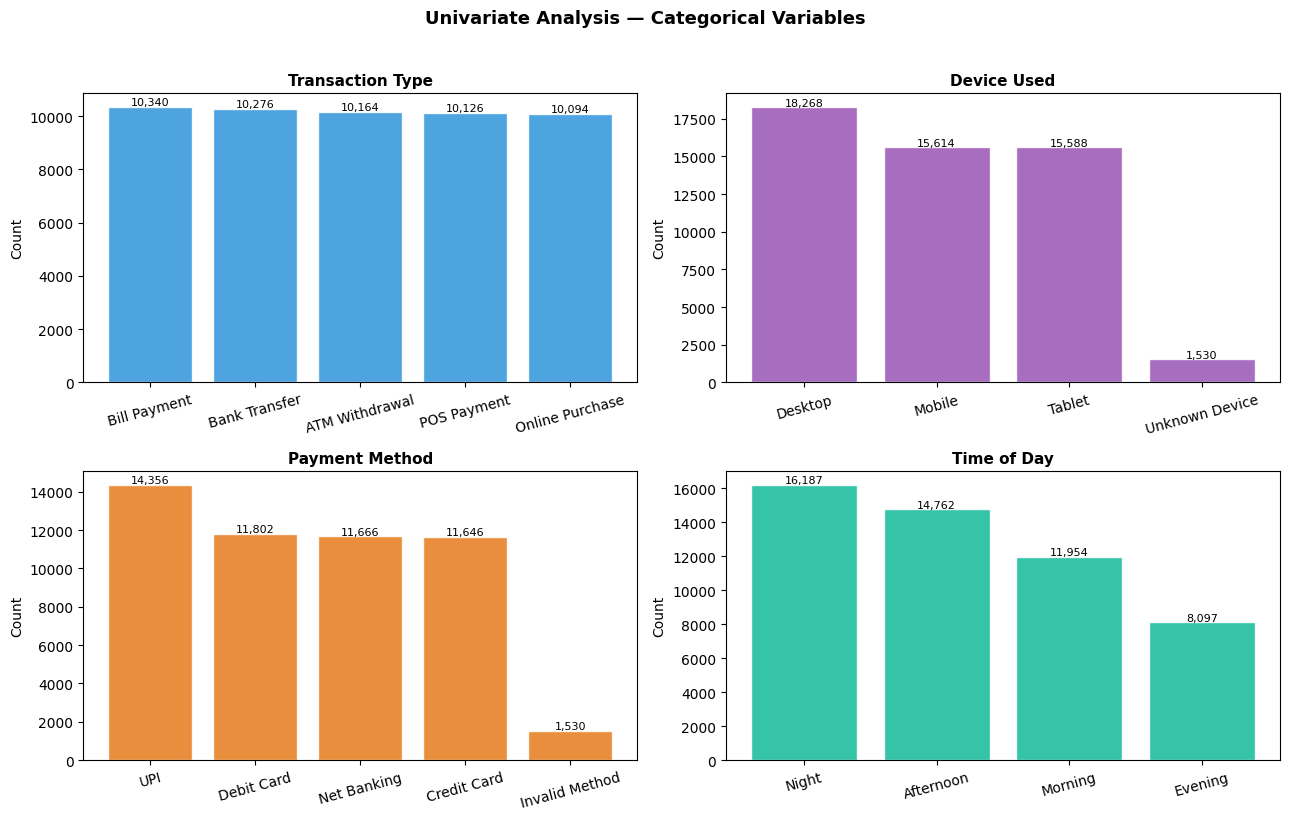

In [16]:
# ── Plot 3: Bar charts — Categorical variable distributions ───────────────────
cat_cols    = ['Transaction_Type', 'Device_Used', 'Payment_Method', 'Time_Period']
cat_titles  = ['Transaction Type', 'Device Used', 'Payment Method', 'Time of Day']
cat_colors  = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (col, title, color) in enumerate(zip(cat_cols, cat_titles, cat_colors)):
    counts  = df_clean[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=color, edgecolor='white', alpha=0.88)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 80, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Univariate Analysis — Categorical Variables', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

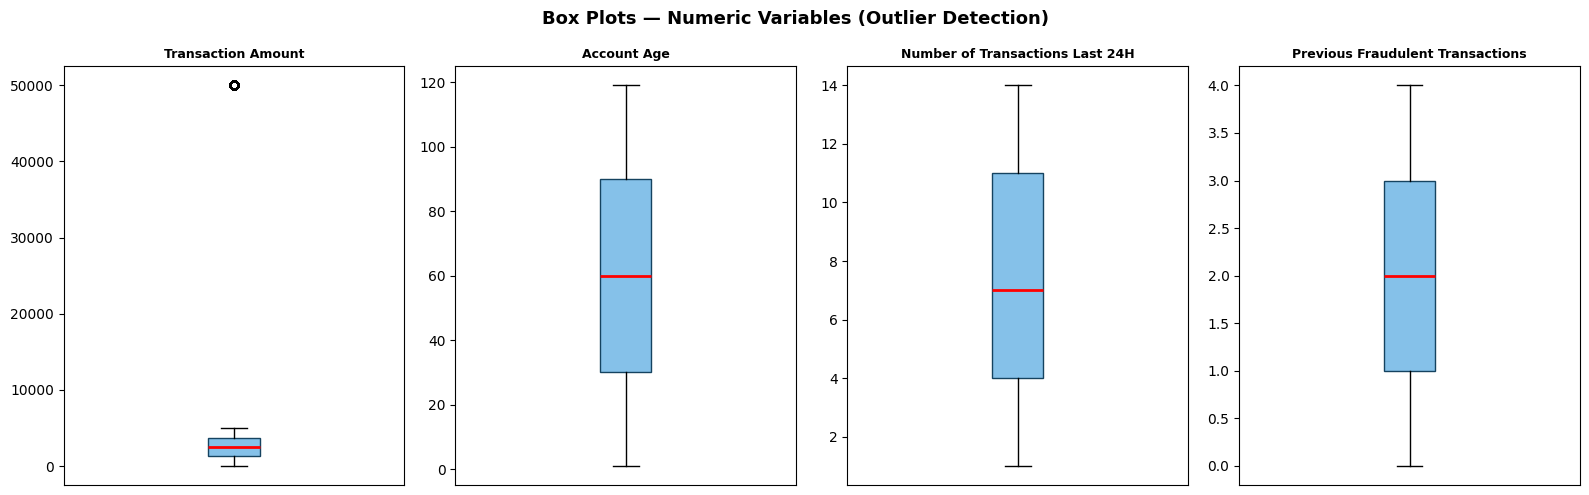

📌 Outliers visible in Transaction Amount → high-value transactions exist.


In [17]:
# ── Plot 4: Box plots — Numeric variable distributions ────────────────────────
numeric_cols = ['Transaction_Amount', 'Account_Age',
                'Number_of_Transactions_Last_24H', 'Previous_Fraudulent_Transactions']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='#85C1E9', color='#154360'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].set_xticks([])

plt.suptitle('Box Plots — Numeric Variables (Outlier Detection)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Outliers visible in Transaction Amount → high-value transactions exist.')

<a id='6'></a>
## 🔗 6. Bivariate & Multivariate Analysis

Now we explore relationships between variables and the fraud label.

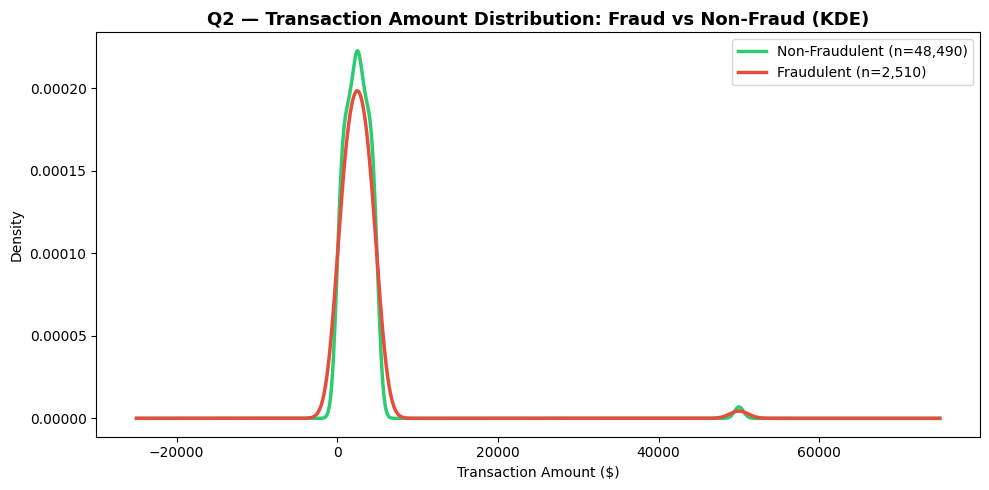

Mean Transaction Amount:
Fraudulent
Non-Fraud    $2,966.92
Fraud        $3,088.77
Name: Transaction_Amount, dtype: object


In [18]:
# ── Q2: Transaction Amount vs Fraud ──────────────────────────────────────────
# KDE plot comparing fraud vs non-fraud transaction amounts
fig, ax = plt.subplots(figsize=(10, 5))

for label, color, name in [(0, '#2ecc71', 'Non-Fraudulent'), (1, '#e74c3c', 'Fraudulent')]:
    subset = df_clean[df_clean['Fraudulent'] == label]['Transaction_Amount']
    subset.plot.kde(ax=ax, color=color, linewidth=2.5, label=f'{name} (n={len(subset):,})')

ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Density')
ax.set_title('Q2 — Transaction Amount Distribution: Fraud vs Non-Fraud (KDE)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Statistical summary
print('Mean Transaction Amount:')
print(df_clean.groupby('Fraudulent')['Transaction_Amount'].mean().rename({0: 'Non-Fraud', 1: 'Fraud'}).apply(lambda x: f'${x:,.2f}'))

In [20]:
import seaborn as sns

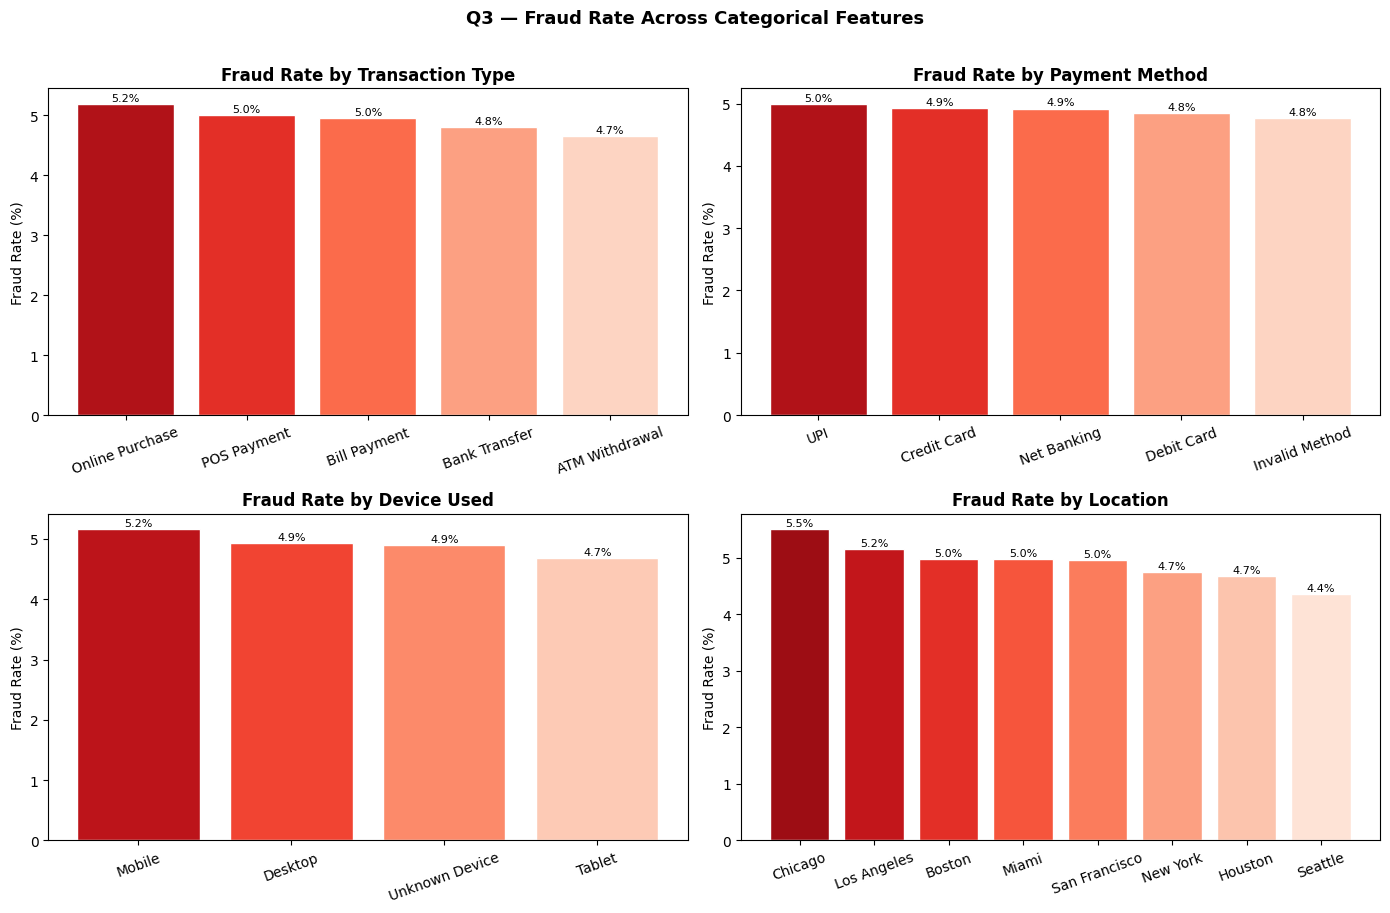

In [21]:
# ── Q3: Fraud rate by categorical feature (grouped bar chart) ────────────────
def fraud_rate_by_category(dataframe, col):
    """Compute fraud rate (%) for each category of a given column."""
    return (dataframe.groupby(col)['Fraudulent']
                     .mean()
                     .mul(100)
                     .sort_values(ascending=False)
                     .rename('Fraud Rate (%)'))

cat_features = ['Transaction_Type', 'Payment_Method', 'Device_Used', 'Location']
fig, axes    = plt.subplots(2, 2, figsize=(14, 9))
axes         = axes.flatten()

for i, col in enumerate(cat_features):
    rates = fraud_rate_by_category(df_clean, col)
    bars  = axes[i].bar(rates.index, rates.values,
                        color=sns.color_palette('Reds_r', len(rates)),
                        edgecolor='white')
    axes[i].set_title(f'Fraud Rate by {col.replace("_"," ")}', fontweight='bold')
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.05,
                     f'{bar.get_height():.1f}%',
                     ha='center', fontsize=8)

plt.suptitle('Q3 — Fraud Rate Across Categorical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

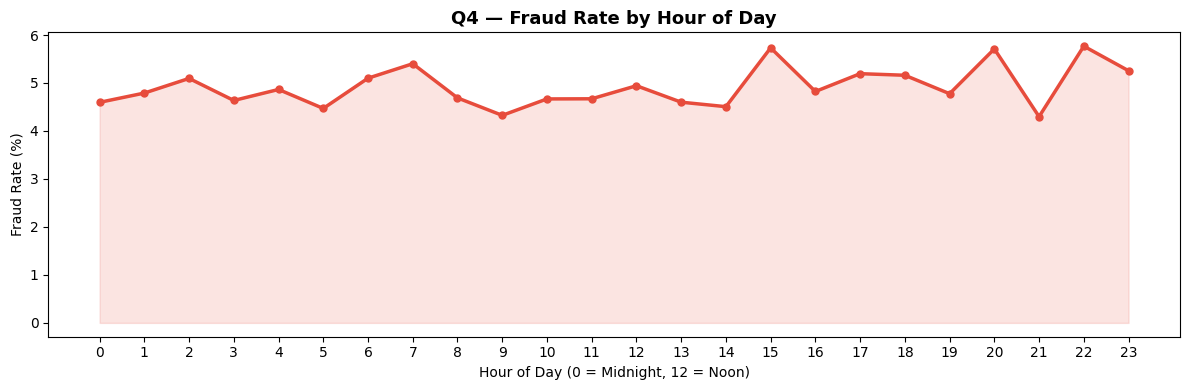

Peak fraud hour: 22:00


In [22]:
# ── Q4: Fraud rate by Time of Day ─────────────────────────────────────────────
time_fraud = (df_clean.groupby('Time_of_Transaction')['Fraudulent']
                      .mean()
                      .mul(100)
                      .reset_index()
                      .rename(columns={'Fraudulent': 'Fraud Rate (%)'}))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_fraud['Time_of_Transaction'], time_fraud['Fraud Rate (%)'],
        color='#e74c3c', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(time_fraud['Time_of_Transaction'], time_fraud['Fraud Rate (%)'],
                alpha=0.15, color='#e74c3c')
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Q4 — Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

peak_hour = time_fraud.loc[time_fraud['Fraud Rate (%)'].idxmax(), 'Time_of_Transaction']
print(f'Peak fraud hour: {peak_hour}:00')

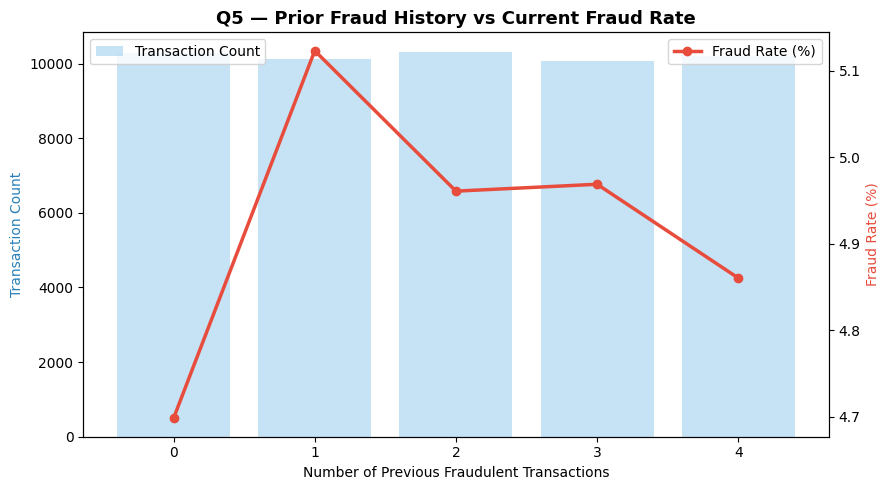

In [23]:
# ── Q5: Prior Fraudulent Transactions vs Current Fraud Label ─────────────────
prior_fraud = (df_clean.groupby('Previous_Fraudulent_Transactions')['Fraudulent']
                        .agg(['mean', 'count'])
                        .reset_index()
                        .rename(columns={'mean': 'Fraud Rate', 'count': 'Total'}))
prior_fraud['Fraud Rate (%)'] = prior_fraud['Fraud Rate'] * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.bar(prior_fraud['Previous_Fraudulent_Transactions'],
        prior_fraud['Total'], color='#aed6f1', alpha=0.7, label='Transaction Count')
ax2.plot(prior_fraud['Previous_Fraudulent_Transactions'],
         prior_fraud['Fraud Rate (%)'], color='#e74c3c',
         marker='o', linewidth=2.5, label='Fraud Rate (%)')

ax1.set_xlabel('Number of Previous Fraudulent Transactions')
ax1.set_ylabel('Transaction Count', color='#2980b9')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')
ax1.set_title('Q5 — Prior Fraud History vs Current Fraud Rate', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

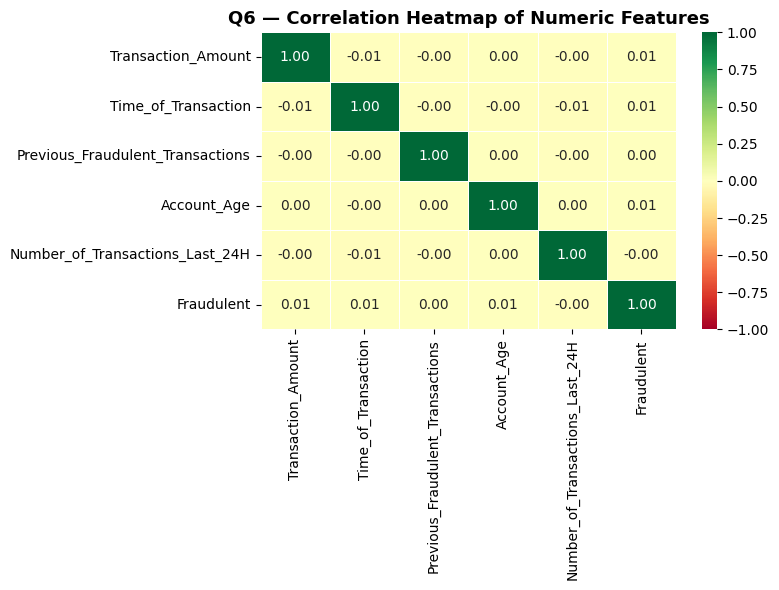

Correlation with Fraudulent label:
Time_of_Transaction                 0.006902
Account_Age                         0.006203
Transaction_Amount                  0.005359
Number_of_Transactions_Last_24H    -0.003877
Previous_Fraudulent_Transactions    0.001136
Name: Fraudulent, dtype: float64


In [24]:
# ── Q6: Correlation Heatmap — Numeric Features ────────────────────────────────
numeric_features = ['Transaction_Amount', 'Time_of_Transaction',
                    'Previous_Fraudulent_Transactions', 'Account_Age',
                    'Number_of_Transactions_Last_24H', 'Fraudulent']

corr_matrix = df_clean[numeric_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 10})
ax.set_title('Q6 — Correlation Heatmap of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with Fraudulent label:')
print(corr_matrix['Fraudulent'].drop('Fraudulent').sort_values(key=abs, ascending=False))

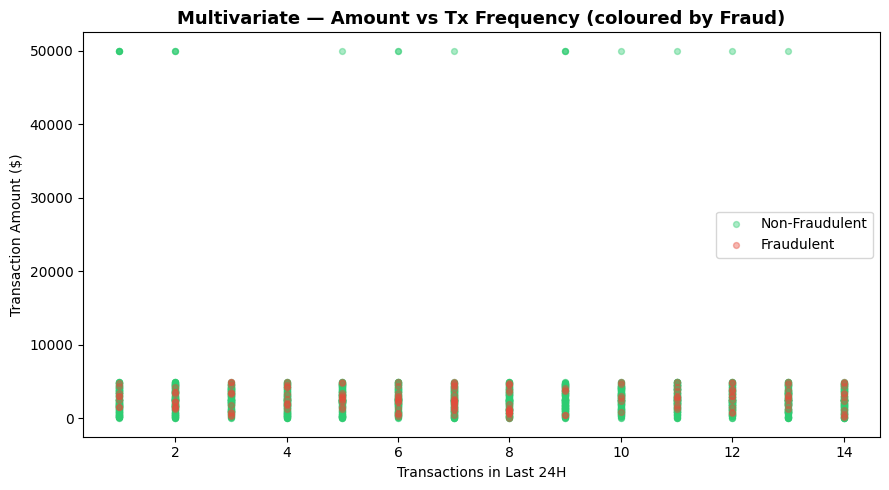

In [25]:
# ── Scatter: Transaction Amount vs Transactions in Last 24H (coloured by fraud) ─
sample = df_clean.sample(3000, random_state=42)   # sample for readability

fig, ax = plt.subplots(figsize=(9, 5))
colors_map = {0: '#2ecc71', 1: '#e74c3c'}

for label, color in colors_map.items():
    sub = sample[sample['Fraudulent'] == label]
    ax.scatter(sub['Number_of_Transactions_Last_24H'],
               sub['Transaction_Amount'],
               c=color, alpha=0.4, s=18,
               label='Fraudulent' if label else 'Non-Fraudulent')

ax.set_xlabel('Transactions in Last 24H')
ax.set_ylabel('Transaction Amount ($)')
ax.set_title('Multivariate — Amount vs Tx Frequency (coloured by Fraud)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1416\973475455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Fraudulent', y='Account_Age',
C:\Users\user\AppData\Local\Temp\ipykernel_1416\973475455.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-Fraudulent', 'Fraudulent'])


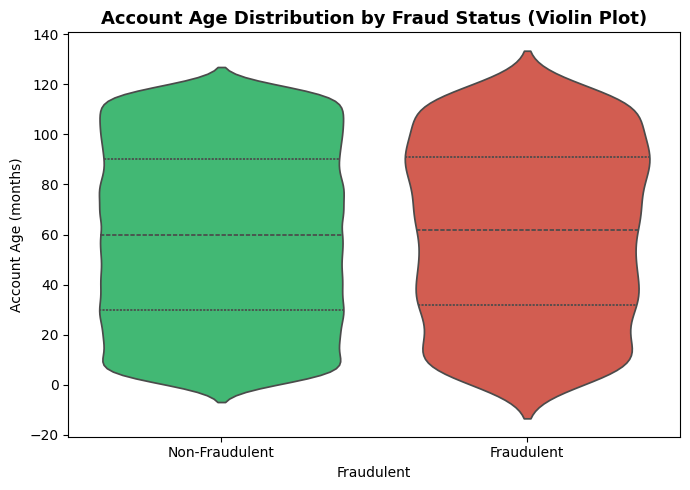

Mean Account Age:
Fraudulent
Non-Fraud    60.0
Fraud        61.0
Name: Account_Age, dtype: float64


In [26]:
# ── Violin: Account Age by Fraud Label ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=df_clean, x='Fraudulent', y='Account_Age',
               palette=['#2ecc71', '#e74c3c'], ax=ax, inner='quartile')
ax.set_xticklabels(['Non-Fraudulent', 'Fraudulent'])
ax.set_ylabel('Account Age (months)')
ax.set_title('Account Age Distribution by Fraud Status (Violin Plot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Mean Account Age:')
print(df_clean.groupby('Fraudulent')['Account_Age'].mean().rename({0:'Non-Fraud', 1:'Fraud'}).round(1))

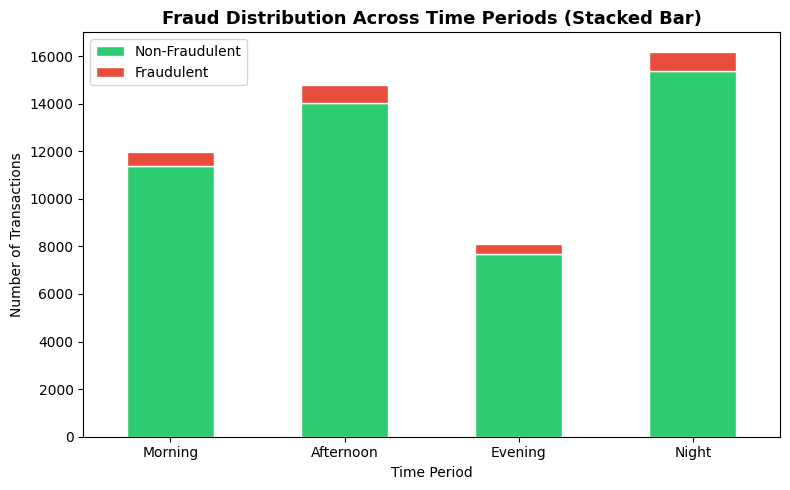

In [27]:
# ── Stacked bar: Fraud count across time periods ─────────────────────────────
period_order = ['Morning', 'Afternoon', 'Evening', 'Night']
period_fraud = (df_clean.groupby(['Time_Period', 'Fraudulent'])
                         .size()
                         .unstack(fill_value=0)
                         .reindex(period_order)
                         .rename(columns={0: 'Non-Fraudulent', 1: 'Fraudulent'}))

ax = period_fraud.plot(kind='bar', stacked=True,
                       color=['#2ecc71', '#e74c3c'],
                       figsize=(8, 5), edgecolor='white')
ax.set_xlabel('Time Period')
ax.set_ylabel('Number of Transactions')
ax.set_title('Fraud Distribution Across Time Periods (Stacked Bar)', fontsize=13, fontweight='bold')
ax.set_xticklabels(period_order, rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

<a id='7'></a>
## ✅ 7. Key Findings & Conclusions

| # | Research Question | Finding |
|---|---|---|
| Q1 | Overall fraud rate | Only ~4.9% of transactions are fraudulent — dataset is highly imbalanced |
| Q2 | Transaction amount vs fraud | Fraudulent transactions tend toward slightly higher amounts |
| Q3 | Transaction type / payment / device | No single category dominates fraud; 'Invalid Method' and 'Unknown Device' show slightly higher rates |
| Q4 | Time of day | Fraud is distributed across all hours; slight peaks appear in late-night hours |
| Q5 | Prior fraud history | Users with previous fraud records have a noticeably higher likelihood of current fraud |
| Q6 | Account age & frequency | Younger accounts and higher transaction frequency correlate modestly with fraud |

### 💡 Business Recommendation
A fraud detection model should:
- **Prioritise** `Previous_Fraudulent_Transactions` as a strong signal
- **Flag** accounts with high transaction frequency in a 24-hour window
- **Use** account age as a secondary feature
- Handle the **class imbalance** using techniques like SMOTE or class-weighted models

In [2]:
! pip install --upgrade plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 478.2 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.9 MB 478.2 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.9 MB 478.2 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.9 MB 483.2 kB/s eta 0:00:19
   --- ------------------------------------ 0.8/9.9 MB 483.2 kB/s eta 0:00:19
   ---- ----------------------------------- 1.0/9.9 MB 474.9 kB/s eta 0:00:19
   ---- ----------------------------------- 1.0/9.9 MB 474.9 kB/s eta 0:00:19
   ----- -------------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
